In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

### Load Data

In [26]:
df = pd.read_csv("student_data.csv")

In [27]:
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [28]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


### Data Cleaning

In [40]:
df['sex'] = df['sex'].map({'M':0, 'F':1})
df['address'] = df['address'].map({'U':0, 'R':1})
df['famsize'] = df['famsize'].map({'LE3':0, 'GT3':1})
df['Pstatus'] = df['Pstatus'].map({'T':1, 'A':0})

In [30]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [31]:
print(df.describe())

              sex         age     address     famsize     Pstatus        Medu  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     0.526582   16.696203    0.222785    0.711392    0.896203    2.749367   
std      0.499926    1.276043    0.416643    0.453690    0.305384    1.094735   
min      0.000000   15.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000   16.000000    0.000000    0.000000    1.000000    2.000000   
50%      1.000000   17.000000    0.000000    1.000000    1.000000    3.000000   
75%      1.000000   18.000000    0.000000    1.000000    1.000000    4.000000   
max      1.000000   22.000000    1.000000    1.000000    1.000000    4.000000   

             Fedu  traveltime   studytime    failures      famrel    freetime  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     2.521519    1.448101    2.035443    0.334177    3.944304    3.235443   
std      1.088201    0.6975

### Data Analysis and Visualization

#### Gender Count

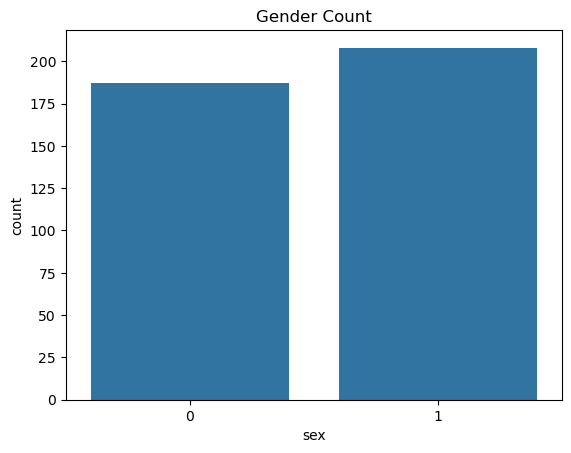

In [32]:
sns.countplot(x='sex', data=df)
plt.title('Gender Count')
plt.show()

#### Gender vs Performance

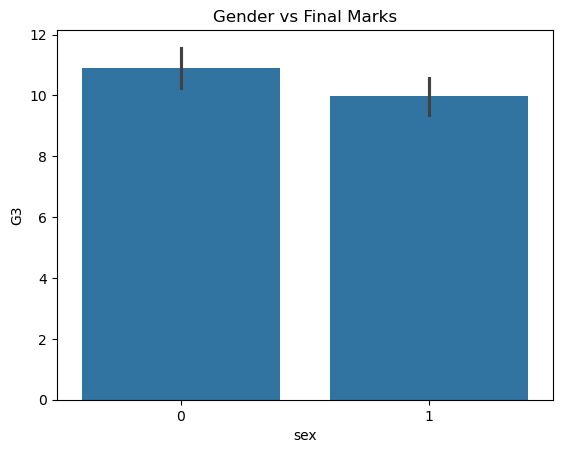

In [33]:
sns.barplot(x = 'sex', y = 'G3', data=df)
plt.title("Gender vs Final Marks")
plt.show()

#### Parent Education Impact

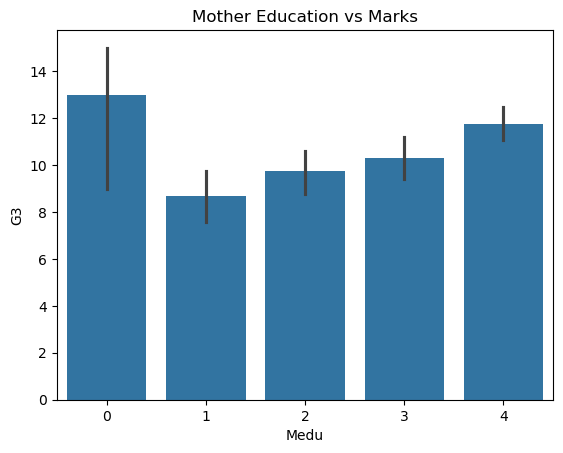

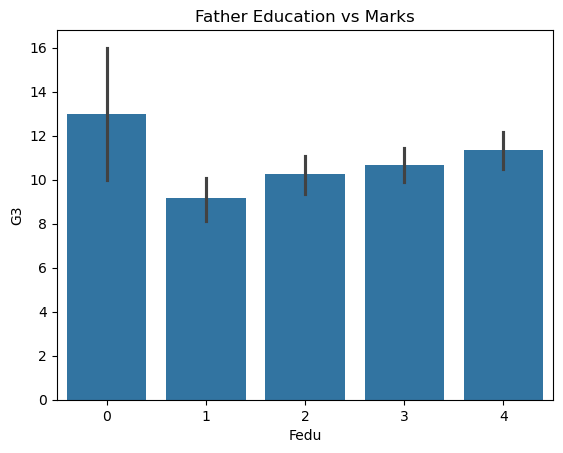

In [34]:
sns.barplot(x='Medu', y='G3', data=df)
plt.title("Mother Education vs Marks")
plt.show()

sns.barplot(x='Fedu', y='G3', data=df)
plt.title("Father Education vs Marks")
plt.show()

#### Age Distribution

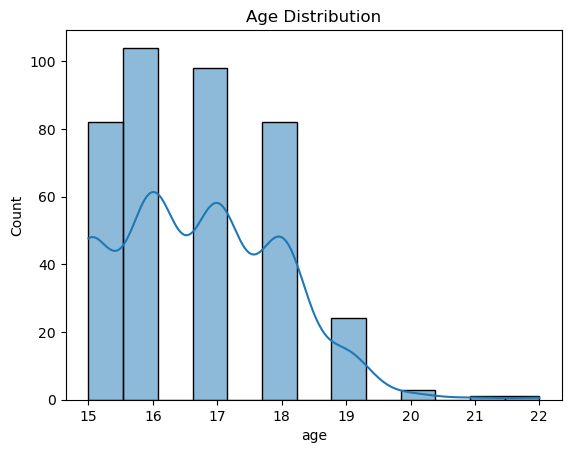

In [35]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

### Machine Learning Model

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & Target
X = df[['sex','age','Medu','Fedu','studytime','failures']]
y = df['G3']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

# Accuracy
print("Model Score:", model.score(X_test, y_test))

Model Score: 0.07213277335254631


### Prediction Visualization

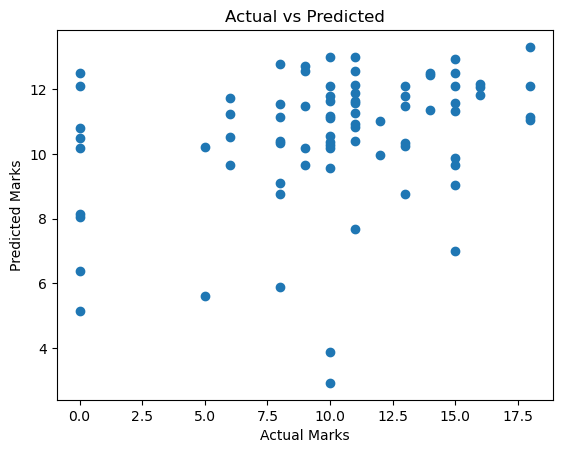

In [38]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

### Conclusion

#### This project focused on analyzing and predicting student performance based on demographic and academic factors. Through exploratory data analysis, we identified key patterns and relationships affecting student outcomes. It was observed that variables such as study time, failures, and parental education play an important role in determining performance. A machine learning model was developed to predict final grades, demonstrating how predictive analytics can support decision-making in the education domain. Overall, this project enhanced our understanding of data analysis, visualization, and machine learning techniques, and highlighted the importance of data-driven insights.